# CS316 Project — Fresh and Rotten Fruits Classifier


---

This notebook contains the code for the fresh and rotten fruits classification and clustering models, and incorporating:
- Loading the dataset
- Creating a DataFrame
- Checking/cleaning data using pandas
- Converting images into simple numeric pixel arrays
- Spliting data into training and testing sets
- Scaling the data using `StandardScaler`
- Training one binary classification model using Adam
- Training one multiclass classification model using Adam
- Performing clustering with K-Means and DBSCAN
- Evaluating using familiar metrics and plots


## Section 1: Import Libraries


---



*These are the main libraries used in the notebook*

In [ ]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.metrics import roc_curve, auc
from scipy.stats import mode

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

sns.set(style='whitegrid')

print('Libraries imported successfully!')

Libraries imported successfully!


## Section 2: Download Dataset from Kaggle


---

*Downloading the images dataset to properly adopt classification and clustering models*

In [ ]:
# Install kagglehub if needed
try:
    import kagglehub
except ImportError:
    !pip install kagglehub
    import kagglehub

# Download dataset from Kaggle
print('Downloading dataset...')
dataset_path = Path(kagglehub.dataset_download('sriramr/fruits-fresh-and-rotten-for-classification'))

# Find the folder that contains train and test
main_dir = None
for folder in [dataset_path] + [p for p in dataset_path.rglob('*') if p.is_dir()]:
    if (folder / 'train').exists() and (folder / 'test').exists():
        main_dir = folder
        break

if main_dir is None:
    raise FileNotFoundError('Could not find train and test folders. Please check the dataset structure.')

train_dir = main_dir / 'train'
test_dir = main_dir / 'test'

print('Main dataset folder:', main_dir)
print('Train folder:', train_dir)
print('Test folder:', test_dir)

Using Colab cache for faster access to the 'fruits-fresh-and-rotten-for-classification' dataset.
Main dataset folder: /kaggle/input/fruits-fresh-and-rotten-for-classification/dataset
Train folder: /kaggle/input/fruits-fresh-and-rotten-for-classification/dataset/train
Test folder: /kaggle/input/fruits-fresh-and-rotten-for-classification/dataset/test


## Section 3: Create a DataFrame of Image Paths and Labels


---
Variables include:

- `image_path`: location of the image file
- `split`: into train or test variables
- `multiclass_label`: original folder name, such as freshapples or rottenbananas
- `binary_label`: fresh or rotten

In [ ]:
# This function creates a DataFrame from image folders.
# It loops through each class folder (e.g., freshapples, rottenbanana),
# reads all image file paths, and assigns:
# - multiclass_label (full class name)
# - binary_label (fresh or rotten)
# It also keeps track of whether the image belongs to train or test set.

def create_image_dataframe(folder_path, split_name):
    rows = []  # list to store all data

    # supported image formats
    image_extensions = ['*.jpg', '*.jpeg', '*.png']

    # loop through each class folder (e.g., freshapples)
    for class_folder in folder_path.iterdir():
        if class_folder.is_dir():

            class_name = class_folder.name.lower()  # get class name in lowercase

            # create binary label (fresh / rotten)
            if 'fresh' in class_name:
                binary_label = 'fresh'
            elif 'rotten' in class_name:
                binary_label = 'rotten'
            else:
                binary_label = 'unknown'

            # loop through all image files inside the folder
            for ext in image_extensions:
                for image_file in class_folder.glob(ext):

                    # store data in dictionary
                    rows.append({
                        'image_path': str(image_file),   # path to image
                        'split': split_name,             # train or test
                        'multiclass_label': class_name,  # full class name
                        'binary_label': binary_label     # fresh or rotten
                    })

    # convert list to DataFrame
    return pd.DataFrame(rows)

train_df = create_image_dataframe(train_dir, 'train')
test_df = create_image_dataframe(test_dir, 'test')
project_df = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)

print('Project DataFrame Shape : ', project_df.shape)
print(project_df.head())

Project DataFrame Shape :  (13599, 4)
                                          image_path  split multiclass_label  \
0  /kaggle/input/fruits-fresh-and-rotten-for-clas...  train     rottenbanana   
1  /kaggle/input/fruits-fresh-and-rotten-for-clas...  train     rottenbanana   
2  /kaggle/input/fruits-fresh-and-rotten-for-clas...  train     rottenbanana   
3  /kaggle/input/fruits-fresh-and-rotten-for-clas...  train     rottenbanana   
4  /kaggle/input/fruits-fresh-and-rotten-for-clas...  train     rottenbanana   

  binary_label  
0       rotten  
1       rotten  
2       rotten  
3       rotten  
4       rotten  


## Section 4: Data Checking and Cleaning


---

*Applying EDA concepts to efficiently use the data*

Dataset shape: (13599, 4)
First few rows:
                                          image_path  split multiclass_label  \
0  /kaggle/input/fruits-fresh-and-rotten-for-clas...  train     rottenbanana   
1  /kaggle/input/fruits-fresh-and-rotten-for-clas...  train     rottenbanana   
2  /kaggle/input/fruits-fresh-and-rotten-for-clas...  train     rottenbanana   
3  /kaggle/input/fruits-fresh-and-rotten-for-clas...  train     rottenbanana   
4  /kaggle/input/fruits-fresh-and-rotten-for-clas...  train     rottenbanana   

  binary_label  
0       rotten  
1       rotten  
2       rotten  
3       rotten  
4       rotten  
Missing values:
image_path          0
split               0
multiclass_label    0
binary_label        0
dtype: int64
Duplicate rows: 0
Binary label distribution:
binary_label
rotten    7695
fresh     5904
Name: count, dtype: int64
Multiclass label distribution:
multiclass_label
rottenapples     2943
rottenbanana     2754
freshapples      2088
rottenoranges    1998
freshban

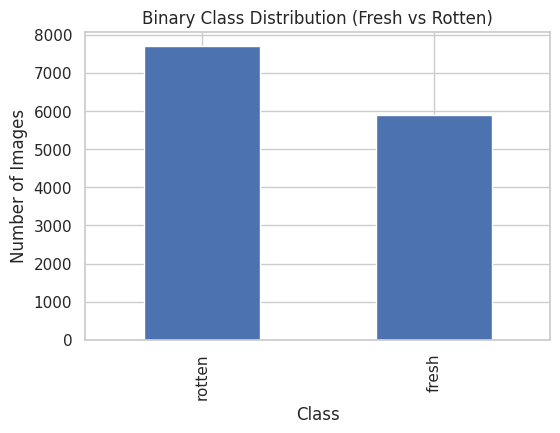

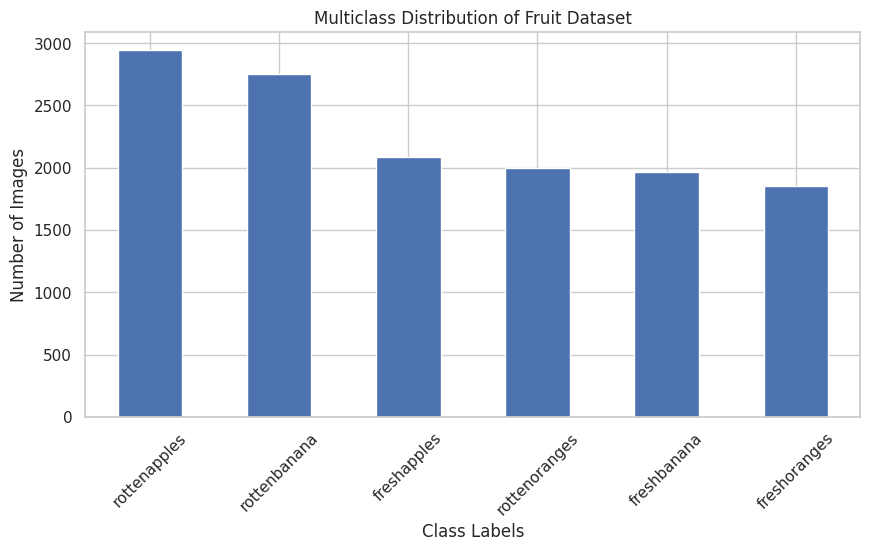

In [ ]:
print('Dataset shape:', project_df.shape)
print('First few rows:')
print(project_df.head())

print('Missing values:')
print(project_df.isnull().sum())

print('Duplicate rows:', project_df.duplicated().sum())
project_df = project_df.drop_duplicates().reset_index(drop=True)

# Remove unknown labels if any exist
project_df = project_df[project_df['binary_label'] != 'unknown'].reset_index(drop=True)

print('Binary label distribution:')
print(project_df['binary_label'].value_counts())

print('Multiclass label distribution:')
print(project_df['multiclass_label'].value_counts())

# ============================
# Binary Label Distribution Plot
# This visualizes the number of fresh vs rotten images in the dataset
# It helps check dataset balance before training
# ============================

plt.figure(figsize=(6,4))

project_df['binary_label'].value_counts().plot(kind='bar')

plt.title('Binary Class Distribution (Fresh vs Rotten)')
plt.xlabel('Class')
plt.ylabel('Number of Images')

plt.show()

# ============================
# Multiclass Label Distribution Plot
# This shows distribution across all fruit categories
# Helps identify class imbalance in dataset
# ============================

plt.figure(figsize=(10,5))

project_df['multiclass_label'].value_counts().plot(kind='bar')

plt.title('Multiclass Distribution of Fruit Dataset')
plt.xlabel('Class Labels')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)

plt.show()

## Section 5: Convert Images to Numeric Arrays


---

*Images are converted to numeric arrays so they can be used in learning models because algorithms only understand numbers and it enables comparison*

In [ ]:
# This section converts images into numeric arrays so they can be used by the models.
# Each image is resized to a fixed size (32x32), converted to RGB, normalized,
# and flattened into a 1D array of pixel values.

IMAGE_SIZE = (32, 32)  # resize all images to same size

# Function to convert image → numeric array
def image_to_array(image_path, image_size=IMAGE_SIZE):

    img = Image.open(image_path).convert('RGB')  # open image and convert to RGB
    img = img.resize(image_size)                 # resize image (32x32)

    arr = np.array(img) / 255.0                  # normalize pixels (0 → 1)

    return arr.flatten()                         # convert to 1D array

X_images = np.array(project_df['image_path'].apply(image_to_array).tolist())

print('X_images shape:', X_images.shape)
print('Each image is represented using', X_images[1], 'pixel values.')

X_images shape: (13599, 3072)
Each image is represented using [0. 0. 0. ... 0. 0. 0.] pixel values.


## Section 6: Binary Classification: Fresh vs Rotten


---


This model predicts only two classes:

- fresh
- rotten

We use one simple neural network model with the Adam optimizer.

In [ ]:
# This section prepares the target labels for binary classification (fresh vs rotten).
# It converts text labels into numeric values (0 and 1), then splits the data into training and testing sets while preserving class distribution.

# Target for binary classification
y_binary = project_df['binary_label']  # take fresh/rotten labels

# Convert labels from text to numbers (fresh=0, rotten=1)
binary_encoder = LabelEncoder()
y_binary_encoded = binary_encoder.fit_transform(y_binary)

print('Binary classes:', binary_encoder.classes_)  # check encoding

# Split the data into training and testing sets
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_images,                 # input features (images as numbers)
    y_binary_encoded,         # target labels (0/1)
    test_size=0.2,            # 20% for testing
    random_state=42,          # fixed split (reproducible)
    stratify=y_binary_encoded # keep same ratio of classes
)

# Print sizes
print('Training sample size:', X_train_bin.shape[0])
print('Training feature size:', X_train_bin.shape[1])
print('Testing sample size:', X_test_bin.shape[0])
print('Testing feature size:', X_test_bin.shape[1])

Binary classes: ['fresh' 'rotten']
Training sample size: 10879
Training feature size: 3072
Testing sample size: 2720
Testing feature size: 3072


### Scale Binary Classification Data



In [ ]:
# This section scales the binary classification data and trains a simple neural network model.

# Scale the data
scaler_bin = StandardScaler()
X_train_bin_scaled = scaler_bin.fit_transform(X_train_bin)  # fit on training
X_test_bin_scaled = scaler_bin.transform(X_test_bin)        # apply same scaling to test

print('Binary data scaled successfully!')

Binary data scaled successfully!


### Train Binary Classification Model Using Adam

In [ ]:
# The model uses fully connected layers (Dense) with ReLU activation,
# and a sigmoid output layer for binary classification (fresh vs rotten).
# It is trained using the Adam optimizer and evaluated using accuracy.

# Fix randomness (same results every run)
tf.random.set_seed(42)

# Build the model
binary_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_bin_scaled.shape[1],)),  # layer 1
    Dense(64, activation='relu'),                                               # layer 2
    Dense(1, activation='sigmoid')                                              # output (binary)
])

# Compile the model
binary_model.compile(
    optimizer='adam',                 # learning method
    loss='binary_crossentropy',       # loss for binary
    metrics=['accuracy']              # evaluation metric
)

# Train the model
binary_history = binary_model.fit(
    X_train_bin_scaled,
    y_train_bin,
    epochs=10,            # train 10 times
    batch_size=32,        # 32 images per step
    validation_split=0.2, # 20% validation
    verbose=1
)
print('Binary classification model trained successfully!')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8730 - loss: 0.3197 - val_accuracy: 0.9040 - val_loss: 0.2154
Epoch 2/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9340 - loss: 0.1748 - val_accuracy: 0.9214 - val_loss: 0.1930
Epoch 3/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9579 - loss: 0.1100 - val_accuracy: 0.9393 - val_loss: 0.1613
Epoch 4/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9654 - loss: 0.0847 - val_accuracy: 0.9481 - val_loss: 0.1401
Epoch 5/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9704 - loss: 0.0792 - val_accuracy: 0.9347 - val_loss: 0.1847
Epoch 6/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9735 - loss: 0.0718 - val_accuracy: 0.9357 - val_loss: 0.2290
Epoch 7/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9824 - loss: 0.0491 - val_accuracy: 0.9481 - val_loss: 0.1566
Epoch 8/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9802 - loss: 0.0561 - val_accuracy: 0.

### Evaluate Binary Classification Model

85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Binary Classification Metrics
Accuracy: 0.9400735294117647
Precision: 0.9387755102040817
Recall: 0.9564652371669915
F1-Score: 0.9475378178307049
ROC AUC: 0.9848585382922921
Average Confidence: 0.97719294

Classification Report:
              precision    recall  f1-score   support

       fresh       0.94      0.92      0.93      1181
      rotten       0.94      0.96      0.95      1539

    accuracy                           0.94      2720
   macro avg       0.94      0.94      0.94      2720
weighted avg       0.94      0.94      0.94      2720



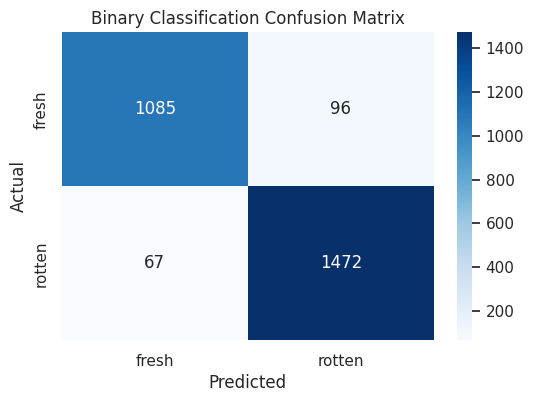

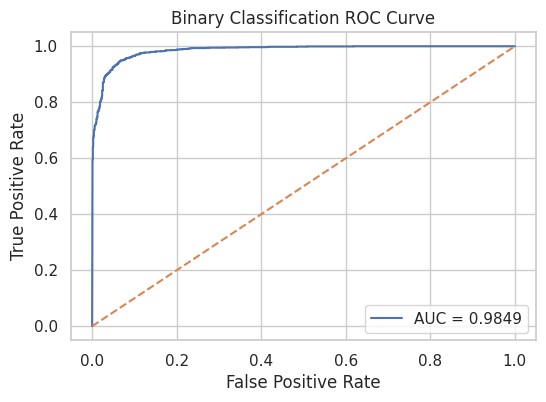

In [ ]:
# Predictions
binary_prob = binary_model.predict(X_test_bin_scaled).flatten()
y_pred_bin = (binary_prob >= 0.5).astype(int)

# Confidence = how sure the model is about its prediction
binary_confidence = np.where(y_pred_bin == 1, binary_prob, 1 - binary_prob)
binary_avg_confidence = binary_confidence.mean()

# Metrics
binary_accuracy = accuracy_score(y_test_bin, y_pred_bin)
binary_precision = precision_score(y_test_bin, y_pred_bin)
binary_recall = recall_score(y_test_bin, y_pred_bin)
binary_f1 = f1_score(y_test_bin, y_pred_bin)
binary_auc = roc_auc_score(y_test_bin, binary_prob)

print('Binary Classification Metrics')
print('Accuracy:', binary_accuracy)
print('Precision:', binary_precision)
print('Recall:', binary_recall)
print('F1-Score:', binary_f1)
print('ROC AUC:', binary_auc)
print('Average Confidence:', binary_avg_confidence)

print('\nClassification Report:')
print(classification_report(y_test_bin, y_pred_bin, target_names=binary_encoder.classes_))

# Confusion Matrix
cm_bin = confusion_matrix(y_test_bin, y_pred_bin)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_bin,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=binary_encoder.classes_,
    yticklabels=binary_encoder.classes_
)
plt.title('Binary Classification Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve
fpr_bin, tpr_bin, thresholds_bin = roc_curve(y_test_bin, binary_prob)

plt.figure(figsize=(6, 4))
plt.plot(fpr_bin, tpr_bin, label=f'AUC = {binary_auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('Binary Classification ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

### Binary Classification Training Curve

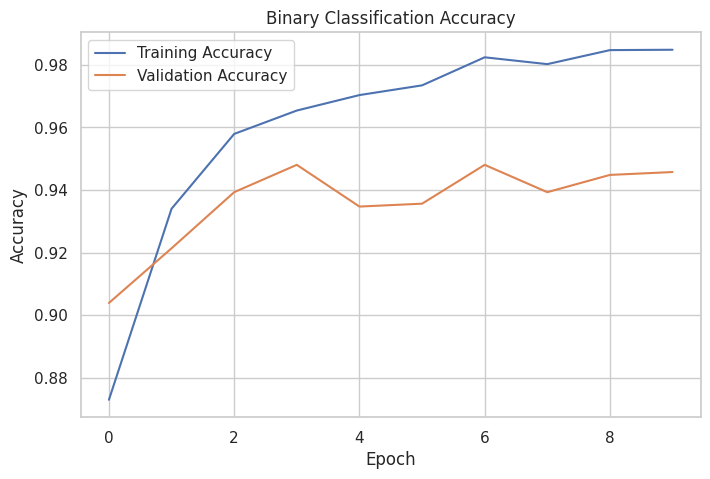

85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


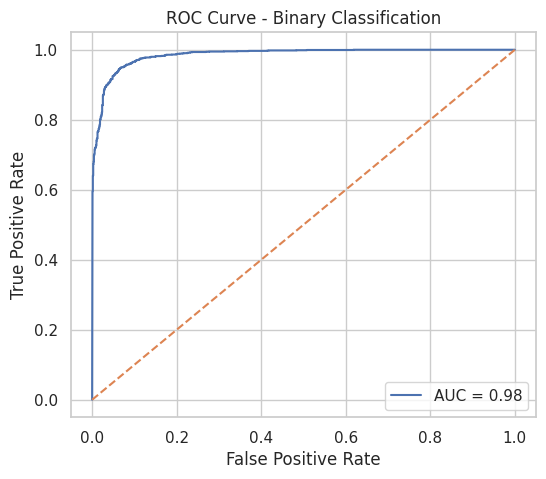

ROC-AUC Score: 0.9848585382922921


In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(binary_history.history['accuracy'], label='Training Accuracy')
plt.plot(binary_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Binary Classification Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# ============================
# ROC Curve Evaluation
# ============================

# Get prediction probabilities
y_prob = binary_model.predict(X_test_bin_scaled).ravel()

# Compute ROC values
fpr, tpr, thresholds = roc_curve(y_test_bin, y_prob)

# Compute AUC score
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.title('ROC Curve - Binary Classification')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

# Print score
print("ROC-AUC Score:", roc_auc)

## Section 7: Multiclass Classification — Fruit Type and Condition


---


This model predicts the original folder classes, such as:

- freshapples
- rottenapples
- freshbanana
- rottenbanana

We use one simple neural network model with the Adam optimizer.

In [ ]:
# This section prepares the target labels for multiclass classification.
# It converts text labels into numeric values, then applies one-hot encoding.
# The data is then split into training and testing sets while keeping class balance.

# Select multiclass target labels
y_multi = project_df['multiclass_label']

# Convert text labels to numbers
multi_encoder = LabelEncoder()
y_multi_encoded = multi_encoder.fit_transform(y_multi)

# Convert numeric labels to one-hot format for the neural network
y_multi_categorical = to_categorical(y_multi_encoded)

# Display class names and number of classes
print('Multiclass classes:', multi_encoder.classes_)
print('Number of classes:', len(multi_encoder.classes_))

# Split data for model training
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_images,
    y_multi_categorical,
    test_size=0.2,
    random_state=42,
    stratify=y_multi_encoded
)

# Keep numeric labels for evaluation, y_multi_encoded labels as integer class indices because evaluation metrics need it
_, _, y_train_multi_labels, y_test_multi_labels = train_test_split(
    X_images,
    y_multi_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_multi_encoded
)

print('Training set size:', X_train_multi.shape[0])
print('Testing set size:', X_test_multi.shape[0])

Multiclass classes: ['freshapples' 'freshbanana' 'freshoranges' 'rottenapples' 'rottenbanana'
 'rottenoranges']
Number of classes: 6
Training set size: 10879
Testing set size: 2720


### Scale Multiclass Classification Data

In [ ]:
# This section scales the multiclass input data using StandardScaler.

# Scale the multiclass data
scaler_multi = StandardScaler()
X_train_multi_scaled = scaler_multi.fit_transform(X_train_multi)
X_test_multi_scaled = scaler_multi.transform(X_test_multi)

print('Multiclass data scaled successfully!')

Multiclass data scaled successfully!


### Train Multiclass Classification Model Using Adam

In [ ]:
# This section builds and trains a neural network model for multiclass classification.
# The model uses Dense layers with ReLU activation to predict probabilities for each class. It is trained using the Adam optimizer.

# Set random seed for reproducibility
tf.random.set_seed(42)

# Buils the model
multiclass_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_multi_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dense(len(multi_encoder.classes_), activation='softmax')
])

# Compile the model
multiclass_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
multiclass_history = multiclass_model.fit(
    X_train_multi_scaled,
    y_train_multi,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

print('Multiclass classification model trained successfully!')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7798 - loss: 0.6397 - val_accuracy: 0.8474 - val_loss: 0.4646
Epoch 2/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8772 - loss: 0.3517 - val_accuracy: 0.8759 - val_loss: 0.3553
Epoch 3/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9144 - loss: 0.2347 - val_accuracy: 0.8961 - val_loss: 0.3380
Epoch 4/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9346 - loss: 0.1909 - val_accuracy: 0.8980 - val_loss: 0.3454
Epoch 5/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9454 - loss: 0.1540 - val_accuracy: 0.8943 - val_loss: 0.3503
Epoch 6/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9529 - loss: 0.1309 - val_accuracy: 0.8938 - val_loss: 0.4224
Epoch 7/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9555 - loss: 0.1205 - val_accuracy: 0.8915 - val_loss: 0.4385
Epoch 8/10
272/272 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9573 - loss: 0.1374 - val_accuracy: 0.

### Evaluate Multiclass Classification Model

85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Multiclass Classification Metrics
Accuracy: 0.9007352941176471
Precision: 0.9016008250813274
Recall: 0.9007352941176471
F1-Score: 0.8996784932758636
ROC AUC: 0.9897414769398856
Average Confidence: 0.9656776

Classification Report:
               precision    recall  f1-score   support

  freshapples       0.86      0.94      0.90       418
  freshbanana       0.90      0.97      0.93       392
 freshoranges       0.90      0.93      0.91       371
 rottenapples       0.88      0.86      0.87       589
 rottenbanana       0.96      0.95      0.96       551
rottenoranges       0.90      0.76      0.83       399

     accuracy                           0.90      2720
    macro avg       0.90      0.90      0.90      2720
 weighted avg       0.90      0.90      0.90      2720



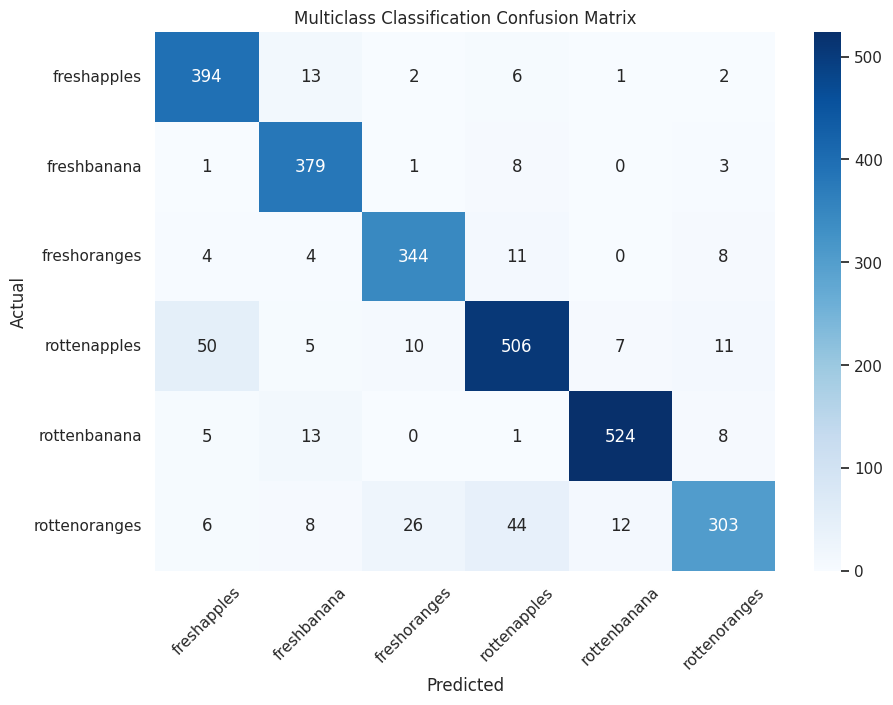

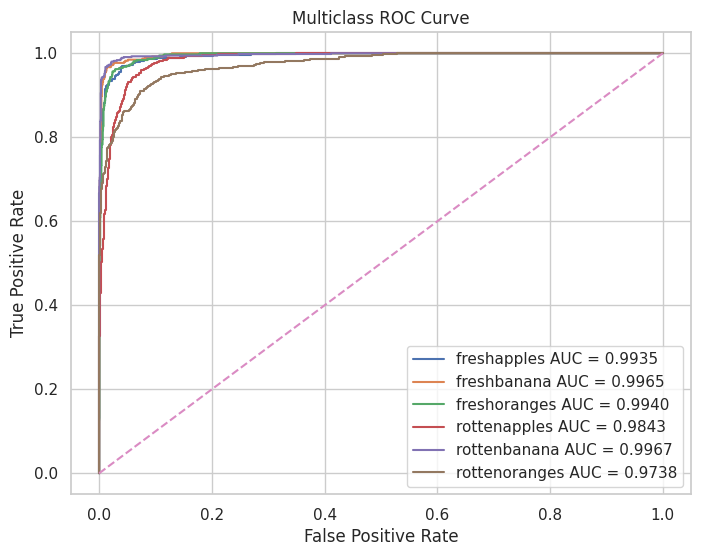

In [ ]:
# Predictions
y_pred_multi_prob = multiclass_model.predict(X_test_multi_scaled)
y_pred_multi = np.argmax(y_pred_multi_prob, axis=1)

# Confidence = highest predicted probability
multiclass_confidence = np.max(y_pred_multi_prob, axis=1)
multiclass_avg_confidence = multiclass_confidence.mean()

# Metrics
multiclass_accuracy = accuracy_score(y_test_multi_labels, y_pred_multi)
multiclass_precision = precision_score(y_test_multi_labels, y_pred_multi, average='weighted')
multiclass_recall = recall_score(y_test_multi_labels, y_pred_multi, average='weighted')
multiclass_f1 = f1_score(y_test_multi_labels, y_pred_multi, average='weighted')
multiclass_auc = roc_auc_score(y_test_multi, y_pred_multi_prob, multi_class='ovr', average='weighted')

print('Multiclass Classification Metrics')
print('Accuracy:', multiclass_accuracy)
print('Precision:', multiclass_precision)
print('Recall:', multiclass_recall)
print('F1-Score:', multiclass_f1)
print('ROC AUC:', multiclass_auc)
print('Average Confidence:', multiclass_avg_confidence)

print('\nClassification Report:')
print(classification_report(y_test_multi_labels, y_pred_multi, target_names=multi_encoder.classes_))

# Confusion Matrix
cm_multi = confusion_matrix(y_test_multi_labels, y_pred_multi)

plt.figure(figsize=(10, 7))
sns.heatmap(
    cm_multi,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=multi_encoder.classes_,
    yticklabels=multi_encoder.classes_
)
plt.title('Multiclass Classification Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

# ROC Curve for each class
plt.figure(figsize=(8, 6))

for i, class_name in enumerate(multi_encoder.classes_):
    fpr, tpr, thresholds = roc_curve(y_test_multi[:, i], y_pred_multi_prob[:, i])
    class_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_name} AUC = {class_auc:.4f}')

plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('Multiclass ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

### Multiclass Classification Training Curve

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(multiclass_history.history['accuracy'], label='Training Accuracy')
plt.plot(multiclass_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Multiclass Classification Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Section 8: Clustering Preparation


---


*Clustering is unsupervised, so the models use `X` only. The labels are kept only for comparison and interpretation.*

In [ ]:
# This section prepares the data for clustering.
# The same image arrays are reused and scaled to improve clustering performance.

# Copy image data for clustering
X_cluster = X_images.copy()

# Scale the data (important for distance-based algorithms like K-Means)
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

# Display shape and confirmation
print('Clustering data shape:', X_cluster_scaled.shape)
print('Clustering data scaled successfully!')

Clustering data shape: (13599, 3072)
Clustering data scaled successfully!


## Section 9: K-Means Clustering


In [ ]:
# This section applies K-Means clustering using a selected number of clusters.
# The clusters are assigned to the dataset, and the distribution of clusters is analyzed.
# The silhouette score is calculated to evaluate how well the data is grouped.

# Use number of classes as K for comparison
optimal_k = len(multi_encoder.classes_)   # set K equal to the number of known class labels

# Train K-Means model
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
kmeans_clusters = kmeans_model.fit_predict(X_cluster_scaled)

# Add cluster labels to dataset
project_df['kmeans_cluster'] = kmeans_clusters

# Show how many samples in each cluster
print('K-Means cluster distribution:')
print(project_df['kmeans_cluster'].value_counts())

# Compute silhouette score (only if more than 1 cluster), measures clustering quality
if optimal_k > 1:
    kmeans_silhouette = silhouette_score(X_cluster_scaled, kmeans_clusters)
else:
    kmeans_silhouette = np.nan

print('K-Means Silhouette Score:', kmeans_silhouette)

K-Means cluster distribution:
kmeans_cluster
4    3913
1    3442
2    2527
0    1376
5    1196
3    1145
Name: count, dtype: int64
K-Means Silhouette Score: 0.10593809814078417


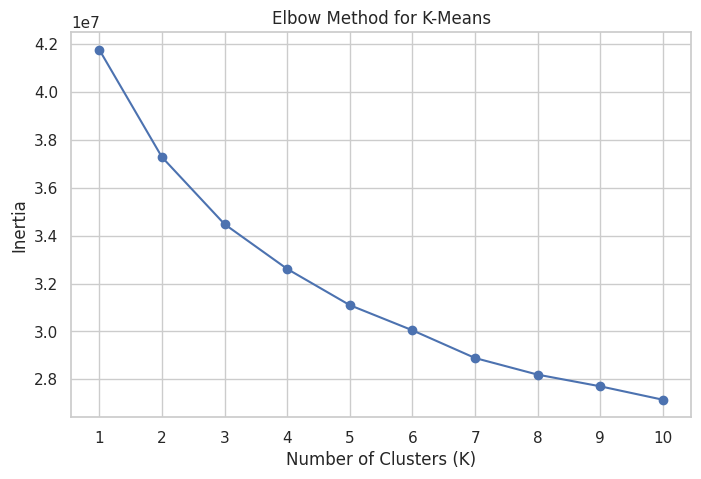

In [ ]:
# This section applies K-Means clustering and uses the elbow method
# to determine the optimal number of clusters (K).
# Inertia is used to measure how well the data is grouped.

inertia = []                  # store inertia values (how tight clusters are)
k_range = range(1, 11)        # try K from 1 to 10 (number of clusters)

# Train K-Means for different K values
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_cluster_scaled)
    inertia.append(kmeans.inertia_)   # store inertia

# Plot Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method for K-Means')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.show()

### Evaluate K-Means Clustering Model

In [ ]:
# Silhouette Score
kmeans_silhouette = silhouette_score(X_cluster_scaled, kmeans_clusters)

# Map clusters to true labels
kmeans_mapped_labels = np.zeros_like(kmeans_clusters)

for cluster in np.unique(kmeans_clusters):
    cluster_indexes = (kmeans_clusters == cluster)
    most_common_label = mode(y_multi_encoded[cluster_indexes], keepdims=True)[0][0]
    kmeans_mapped_labels[cluster_indexes] = most_common_label

# Classification-like metrics
kmeans_accuracy = accuracy_score(y_multi_encoded, kmeans_mapped_labels)
kmeans_precision = precision_score(y_multi_encoded, kmeans_mapped_labels, average='weighted')
kmeans_recall = recall_score(y_multi_encoded, kmeans_mapped_labels, average='weighted')
kmeans_f1 = f1_score(y_multi_encoded, kmeans_mapped_labels, average='weighted')

print('K-Means Evaluation Metrics')
print('Accuracy:', kmeans_accuracy)
print('Precision:', kmeans_precision)
print('Recall:', kmeans_recall)
print('F1-Score:', kmeans_f1)
print('Silhouette Score:', kmeans_silhouette)

K-Means Evaluation Metrics
Accuracy: 0.2921538348407971
Precision: 0.22405262426323644
Recall: 0.2921538348407971
F1-Score: 0.196799961758003
Silhouette Score: 0.10593809814078417


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Section 10: DBSCAN Clustering

DBSCAN is another unsupervised clustering model. It can also label some points as noise using `-1`.

In [ ]:
# This section applies DBSCAN clustering, which groups data based on density.
# DBSCAN can label some points as noise (-1) if they do not belong to any cluster.
# The cluster distribution is analyzed, and the silhouette score is calculated
# only if valid clusters are formed.

# Create DBSCAN model, where eps is the maximum distance between two points for them to be neighbors
dbscan_model = DBSCAN(eps=5, min_samples=5)

# Fit model and get cluster labels
dbscan_clusters = dbscan_model.fit_predict(X_cluster_scaled)

# Add cluster labels to dataset
project_df['dbscan_cluster'] = dbscan_clusters

# Show cluster distribution
print('DBSCAN cluster distribution:')
print(project_df['dbscan_cluster'].value_counts())

# Silhouette score only works if more than one valid cluster exists
unique_dbscan_clusters = set(dbscan_clusters)

if len(unique_dbscan_clusters) > 1 and len(unique_dbscan_clusters) < len(dbscan_clusters):
    dbscan_silhouette = silhouette_score(X_cluster_scaled, dbscan_clusters)
else:
    dbscan_silhouette = np.nan

print('DBSCAN Silhouette Score:', dbscan_silhouette)

DBSCAN cluster distribution:
dbscan_cluster
-1    13599
Name: count, dtype: int64
DBSCAN Silhouette Score: nan


### Evaluate DBSCAN Clustering Model

In [ ]:
real_dbscan_clusters = set(dbscan_clusters) - {-1}

if len(real_dbscan_clusters) >= 2:
    dbscan_silhouette = silhouette_score(X_cluster_scaled, dbscan_clusters)

    dbscan_mapped_labels = np.zeros_like(dbscan_clusters)

    for cluster in real_dbscan_clusters:
        cluster_indexes = (dbscan_clusters == cluster)
        most_common_label = mode(y_multi_encoded[cluster_indexes], keepdims=True)[0][0]
        dbscan_mapped_labels[cluster_indexes] = most_common_label

    valid_indexes = dbscan_clusters != -1

    dbscan_accuracy = accuracy_score(y_multi_encoded[valid_indexes], dbscan_mapped_labels[valid_indexes])
    dbscan_precision = precision_score(y_multi_encoded[valid_indexes], dbscan_mapped_labels[valid_indexes], average='weighted')
    dbscan_recall = recall_score(y_multi_encoded[valid_indexes], dbscan_mapped_labels[valid_indexes], average='weighted')
    dbscan_f1 = f1_score(y_multi_encoded[valid_indexes], dbscan_mapped_labels[valid_indexes], average='weighted')

else:
    dbscan_silhouette = np.nan
    dbscan_accuracy = np.nan
    dbscan_precision = np.nan
    dbscan_recall = np.nan
    dbscan_f1 = np.nan

print('DBSCAN Evaluation Metrics')
print('Accuracy:', dbscan_accuracy)
print('Precision:', dbscan_precision)
print('Recall:', dbscan_recall)
print('F1-Score:', dbscan_f1)
print('Silhouette Score:', dbscan_silhouette)

DBSCAN Evaluation Metrics
Accuracy: nan
Precision: nan
Recall: nan
F1-Score: nan
Silhouette Score: nan


## Section 11: Final Results Summary

In [ ]:
results_summary = pd.DataFrame({
    'Model': [
        'Binary Classification Model (Adam)',
        'Multiclass Classification Model (Adam)',
        'K-Means Clustering',
        'DBSCAN Clustering'
    ],
    'Learning Type': [
        'Supervised',
        'Supervised',
        'Unsupervised',
        'Unsupervised'
    ],
    'Accuracy': [
        binary_accuracy,
        multiclass_accuracy,
        kmeans_accuracy,
        dbscan_accuracy
    ],
    'Precision': [
        binary_precision,
        multiclass_precision,
        kmeans_precision,
        dbscan_precision
    ],
    'Recall': [
        binary_recall,
        multiclass_recall,
        kmeans_recall,
        dbscan_recall
    ],
    'F1-Score': [
        binary_f1,
        multiclass_f1,
        kmeans_f1,
        dbscan_f1
    ],
    'ROC AUC': [
        binary_auc,
        multiclass_auc,
        np.nan,
        np.nan
    ],
    'Average Confidence': [
        binary_avg_confidence,
        multiclass_avg_confidence,
        np.nan,
        np.nan
    ],
    'Silhouette Score': [
        np.nan,
        np.nan,
        kmeans_silhouette,
        dbscan_silhouette
    ]
})

# Round numeric values
results_summary = results_summary.round(4)

# Display table
display(results_summary)

,Model,Learning Type,Accuracy,Precision,Recall,F1-Score,ROC AUC,Average Confidence,Silhouette Score
0,Binary Classification Model (Adam),Supervised,0.9401,0.9388,0.9565,0.9475,0.9849,0.9772,NaN
1,Multiclass Classification Model (Adam),Supervised,0.9007,0.9016,0.9007,0.8997,0.9897,0.9657,NaN
2,K-Means Clustering,Unsupervised,0.2922,0.2241,0.2922,0.1968,NaN,NaN,0.1059
3,DBSCAN Clustering,Unsupervised,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
binary_model.save("binary_model.h5")
from google.colab import files
files.download("binary_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Final Interpretation

- The binary classification model predicts whether the fruit is fresh or rotten.
- The multiclass classification model predicts the exact fruit/condition class.
- K-Means and DBSCAN are unsupervised models, so their scores are not directly the same as classification accuracy.
- Classification uses labels during training, while clustering tries to find groups without using labels.